# Phase 7 — Feature Study

**Project:** “Machine Learning approaches for accelerating antibiotic susceptibility testing (AST) in microfluidic systems” 

**Date:** May 2026 

## 1. Introduction

This notebook systematically evaluates the impact of adding and removing individual features on the Random Forest model performance, building on the results of Phase 6.

### Objectives
- Evaluate the effect of adding the top new features (`gvr_max_tube`, `auc_per_time`)
  to the original feature set
- Identify which original features contribute negatively to model performance
- Determine the optimal feature set for early and reliable growth prediction

### Input
- `ecoli_ampli_expanded.csv` — expanded labelled feature matrix from Phase 5

### Methodology
Each feature combination is evaluated per timepoint on two independent test experiments, using the same train/test split strategy as previous phases. The reliable prediction timepoint is used as the main comparison metric.

## Table of Contents
1. [Introduction](#1-introduction)
2. [Imports & Setup](#2-imports--setup)
3. [Data Loading & Preparation](#3-data-loading--preparation)
4. [Original Features + Top 2 New](#4-original-features--top-2-new-ones)
5. [Original + gvr_max_tube](#5-original--gvr_max_tube)
6. [Original + auc_per_time](#6-original--auc_per_time)
7. [Without Derivative & initial_std — Best Combination](#7-without-derivative--initial_std-7-features--best-combination)
8. [Conclusions](#8-conclusion)


## 2. Imports & Setup

In [1]:
#  Data manipulation 
import numpy as np
import pandas as pd

# Machine learning 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# -- Visualisação -------
import matplotlib.pyplot as plt

## 3. Data Loading & Preparation

### 3.1 Load dataset

In [2]:
# Load expanded feature matrix from Phase 5
for_ml = pd.read_csv("ecoli_ampli_expanded.csv")

print(f"Dataset shape: {for_ml.shape}")
for_ml.head()

Dataset shape: (8420, 24)


,experiencia,tubo_id,tempo,antibiotico,concentração,gvr,std_inicial,std_atual,std_tubo,slope,...,delta_por_tempo,Derivada_por_tempo,gvr_media,gvr_max_tubo,gvr_min_tubo,gvr_max_experiencia,gvr_min_experiencia,growth_score,growth_score_exp,label
0,20230508_5e6,20230508_5e6_Positive control,0.000000,Ampicillin,Positive control,0.069883,0.008784,0.008784,0.000000,0.000000,...,0.000000,0.000000,0.066011,0.069883,0.069883,0.077113,0.048811,0.000000,0.000000,1
1,20230508_5e6,20230508_5e6_Positive control,0.166667,Ampicillin,Positive control,0.069883,0.008784,0.008784,0.000000,0.000000,...,0.000000,0.000000,0.066011,0.069883,0.069883,0.077113,0.048811,0.000000,0.000000,1
2,20230508_5e6,20230508_5e6_Positive control,0.333333,Ampicillin,Positive control,-0.139765,0.008784,0.017568,0.098829,-0.628944,...,-0.628944,-3.773662,-0.132023,0.069883,-0.139765,-0.097623,-0.154226,-300.000000,-300.000000,1
3,20230508_5e6,20230508_5e6_Positive control,0.500000,Ampicillin,Positive control,-0.199132,0.008784,0.025127,0.121492,-0.538028,...,-0.538028,-0.712396,-0.173866,0.069883,-0.199132,-0.133680,-0.206227,42.475728,31.694078,1
4,20230508_5e6,20230508_5e6_Positive control,0.666667,Ampicillin,Positive control,-0.119479,0.008784,0.024350,0.112185,-0.284042,...,-0.284042,0.716874,-0.088582,0.069883,-0.199132,-0.048963,-0.127436,-40.000000,-49.051471,1


### 3.2 Clean and prepare

In [3]:
#outlier
dataset = for_ml[for_ml["experiencia"] != "20230518_5e5"]
dataset = dataset.drop(columns=["antibiotico"])
dataset = dataset.drop(columns=["concentração"])

dataset = dataset.replace([np.inf, -np.inf], 0)

print(f"Dataset shape after cleaning: {for_ml.shape}")
print("\nMissing values per column:")
print(for_ml.isnull().sum())

Dataset shape after cleaning: (8420, 24)

Missing values per column:
experiencia            0
tubo_id                0
tempo                  0
antibiotico            0
concentração           0
gvr                    0
std_inicial            0
std_atual              0
std_tubo               0
slope                  0
delta                  0
AUC                    0
Derivada               0
auc_por_tempo          0
delta_por_tempo        0
Derivada_por_tempo     0
gvr_media              0
gvr_max_tubo           0
gvr_min_tubo           0
gvr_max_experiencia    0
gvr_min_experiencia    0
growth_score           0
growth_score_exp       0
label                  0
dtype: int64


## 4. Original Features + top 2 new ones

### 4.1 Define Feature Set

In [4]:
#['tempo', 'gvr', 'std_inicial', 'std_atual', 'std_tubo', 'slope', 'delta', 'AUC', 'Derivada']

features_antigas = ['tempo', 'gvr',  'std_inicial', 'std_atual', 'std_tubo', 'slope', 'delta', 'AUC', "Derivada"]
features_selecionadas = ["gvr_max_tubo", "auc_por_tempo"]

features_novas = features_antigas + features_selecionadas

In [5]:
colunas = list(dataset.head(0))
label = colunas[-1]

print("Features:", features_novas)

Features: ['tempo', 'gvr', 'std_inicial', 'std_atual', 'std_tubo', 'slope', 'delta', 'AUC', 'Derivada', 'gvr_max_tubo', 'auc_por_tempo']


### 4.2 Train / Test Split

In [6]:
experiencias = dataset["experiencia"].unique()

# experiencia de teste 1 e 2
exp_teste1 = "20230518_5e4"
exp_teste2 = "20230518_5e6"

# treino: todas as experiencias menos as 2 de teste
df_train = dataset[~dataset["experiencia"].isin([exp_teste1, exp_teste2])]

# teste 1 e teste 2
df_test1 = dataset[dataset["experiencia"] == exp_teste1]
df_test2 = dataset[dataset["experiencia"] == exp_teste2]

X_train = df_train[features_novas]
y_train = df_train["label"]

X_test1 = df_test1[features_novas]
y_test1 = df_test1["label"]

X_test2 = df_test2[features_novas]
y_test2 = df_test2["label"]


print(f"Train size : {len(df_train)} rows")
print(f"Test 1     : {len(df_test1)} rows  ({exp_teste1})")
print(f"Test 2     : {len(df_test2)} rows  ({exp_teste2})")

Train size : 5450 rows
Test 1     : 990 rows  (20230518_5e4)
Test 2     : 990 rows  (20230518_5e6)


In [7]:
print(f"Testeset 1 shape after: {df_test1.shape}")
print(f"Testeset 1 shape after: {df_test2.shape}")
print(f"Train set shape after: {X_train.shape}")

Testeset 1 shape after: (990, 22)
Testeset 1 shape after: (990, 22)
Train set shape after: (5450, 11)


### 4.3 Train Model

In [8]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 4.4 Timepoint Evaluation — Test 1

In [9]:
timepoints = df_test1[df_test1["std_atual"] > 0.05]["tempo"].unique()
accuracies_top2_t1 = []

for t in timepoints:
    df_t  = df_test1[df_test1["tempo"] == t]
    X_t   = df_t[features_novas]
    y_t   = df_t[label]

    preds = model_rf.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_top2_t1.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t:.2f}h  |  Accuracy: {acc:.4f}")
    print(result.to_string(index=False), "\n")

Time: 5.50h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 5.83h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.00h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.17h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.33h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1      

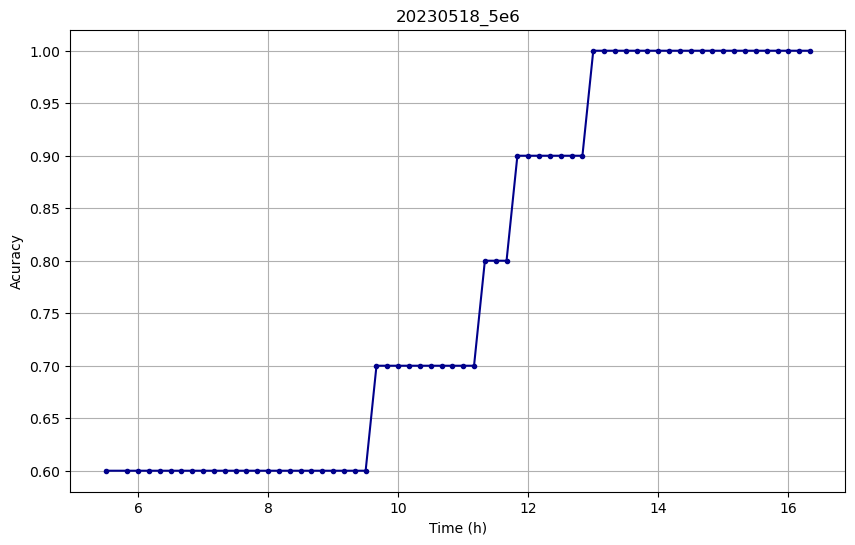

In [10]:
df_results = pd.DataFrame(accuracies_top2_t1)
df_results = df_results.sort_values(by="time")

#Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("20230518_5e6")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

### 4.4 Timepoint Evaluation — Test 2

In [11]:
timepoints = df_test2[df_test2["std_atual"] > 0.05]["tempo"].unique()
accuracies_top2_t2 = []

for t in timepoints:
    df_t  = df_test2[df_test2["tempo"] == t]
    X_t   = df_t[features_novas]
    y_t   = df_t[label]

    preds = model_rf.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_top2_t2.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t:.2f}h  |  Accuracy: {acc:.4f}")
    print(result.to_string(index=False), "\n")

Time: 3.17h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.33h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.50h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.67h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 4.00h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1      

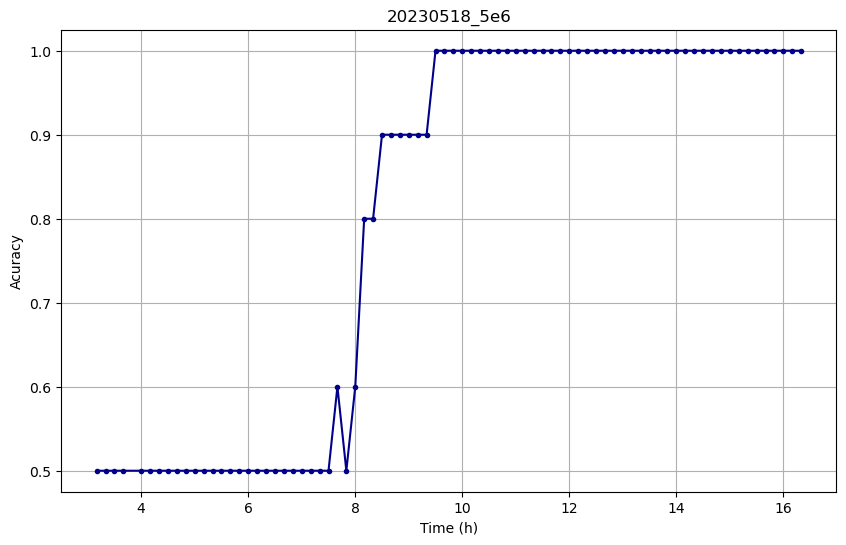

In [12]:
df_results = pd.DataFrame(accuracies_top2_t2)
df_results = df_results.sort_values(by="time")

#Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("20230518_5e6")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

## 5 Original + gvr_max_tube 

In [13]:
#['tempo', 'gvr', 'std_inicial', 'std_atual', 'std_tubo', 'slope', 'delta', 'AUC', 'Derivada']

features_antigas = ['tempo', 'gvr',  'std_inicial', 'std_atual', 'std_tubo', 'slope', 'delta', 'AUC', "Derivada"]
features_selecionadas = ["gvr_max_tubo"]

features_novas = features_antigas + features_selecionadas

##

colunas = list(dataset.head(0))
label = colunas[-1]

print("Features:", features_novas)

###

experiencias = dataset["experiencia"].unique()

# experiencia de teste 1 e 2
exp_teste1 = "20230518_5e4"
exp_teste2 = "20230518_5e6"

# treino: todas as experiencias menos as 2 de teste
df_train = dataset[~dataset["experiencia"].isin([exp_teste1, exp_teste2])]

# teste 1 e teste 2
df_test1 = dataset[dataset["experiencia"] == exp_teste1]
df_test2 = dataset[dataset["experiencia"] == exp_teste2]

X_train = df_train[features_novas]
y_train = df_train["label"]

X_test1 = df_test1[features_novas]
y_test1 = df_test1["label"]

X_test2 = df_test2[features_novas]
y_test2 = df_test2["label"]


print(f"Train size : {len(df_train)} rows")
print(f"Test 1     : {len(df_test1)} rows  ({exp_teste1})")
print(f"Test 2     : {len(df_test2)} rows  ({exp_teste2})")

Features: ['tempo', 'gvr', 'std_inicial', 'std_atual', 'std_tubo', 'slope', 'delta', 'AUC', 'Derivada', 'gvr_max_tubo']
Train size : 5450 rows
Test 1     : 990 rows  (20230518_5e4)
Test 2     : 990 rows  (20230518_5e6)


In [14]:
print(f"Testeset 1 shape after: {df_test1.shape}")
print(f"Testeset 1 shape after: {df_test2.shape}")
print(f"Train set shape after: {X_train.shape}")

Testeset 1 shape after: (990, 22)
Testeset 1 shape after: (990, 22)
Train set shape after: (5450, 10)


### 5.1 treinar e testar

In [15]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 5.2 Test 1

In [16]:
timepoints = df_test1[df_test1["std_atual"] > 0.05]["tempo"].unique()
accuracies_top1_t1 = []

for t in timepoints:
    df_t  = df_test1[df_test1["tempo"] == t]
    X_t   = df_t[features_novas]
    y_t   = df_t[label]

    preds = model_rf.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_top1_t1.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t:.2f}h  |  Accuracy: {acc:.4f}")
    print(result.to_string(index=False), "\n")

Time: 5.50h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 5.83h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.00h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.17h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.33h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1      

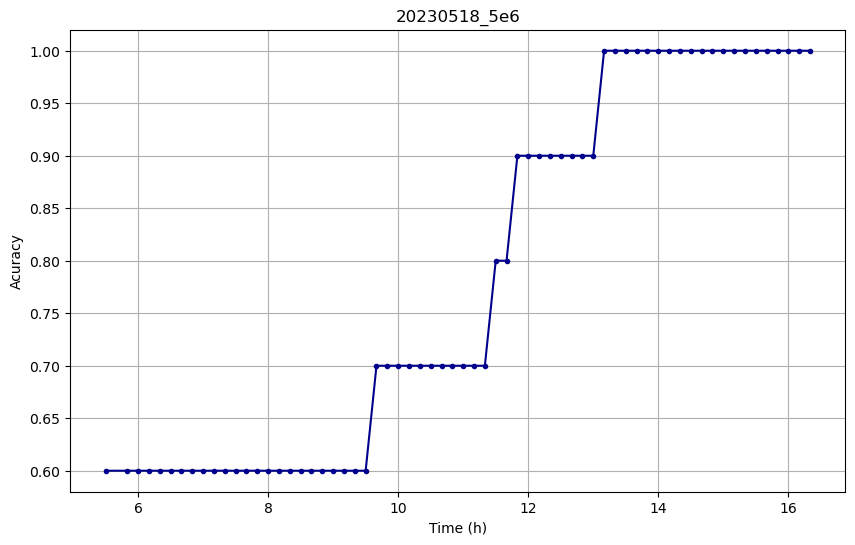

In [17]:
df_results = pd.DataFrame(accuracies_top1_t1)
df_results = df_results.sort_values(by="time")

#Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("20230518_5e6")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

### 5.3 Test 2

In [18]:
timepoints = df_test2[df_test2["std_atual"] > 0.05]["tempo"].unique()
accuracies_top1_t2 = []

for t in timepoints:
    df_t  = df_test2[df_test2["tempo"] == t]
    X_t   = df_t[features_novas]
    y_t   = df_t[label]

    preds = model_rf.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_top1_t2.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t:.2f}h  |  Accuracy: {acc:.4f}")
    print(result.to_string(index=False), "\n")

Time: 3.17h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.33h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.50h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.67h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 4.00h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1      

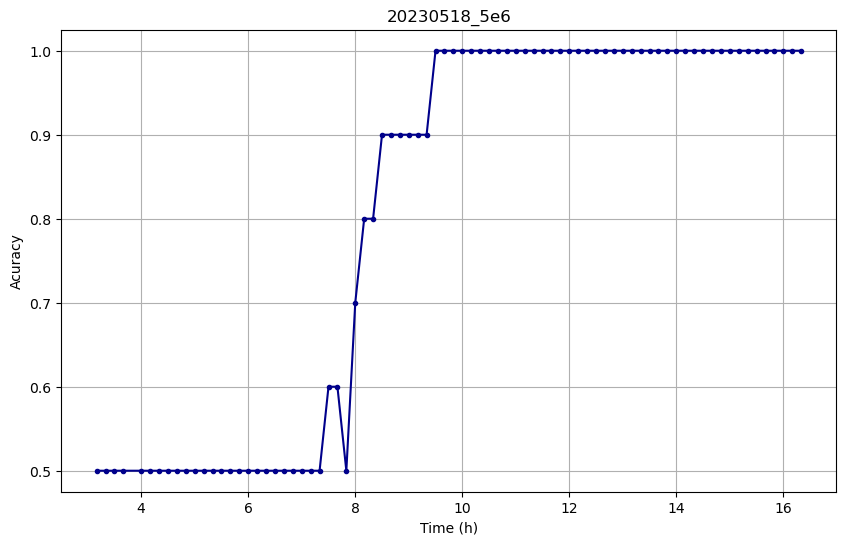

In [19]:
df_results = pd.DataFrame(accuracies_top1_t2)
df_results = df_results.sort_values(by="time")

#Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("20230518_5e6")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

## 6. Original + auc_per_time 

In [20]:
features_antigas = ['tempo', 'gvr',  'std_inicial', 'std_atual', 'std_tubo', 'slope', 'delta', 'AUC', "Derivada"]
features_selecionadas = [ "auc_por_tempo"] 

features_novas = features_antigas + features_selecionadas

colunas = list(dataset.head(0))
label = colunas[-1]
print("Features:", features_novas)

experiencias = dataset["experiencia"].unique()


# experiencia de teste 1 e 2
exp_teste1 = "20230518_5e4"
exp_teste2 = "20230518_5e6"

# treino: todas as experiencias menos as 2 de teste
df_train = dataset[~dataset["experiencia"].isin([exp_teste1, exp_teste2])]

# teste 1 e teste 2
df_test1 = dataset[dataset["experiencia"] == exp_teste1]
df_test2 = dataset[dataset["experiencia"] == exp_teste2]

X_train = df_train[features_novas]
y_train = df_train["label"]

X_test1 = df_test1[features_novas]
y_test1 = df_test1["label"]

X_test2 = df_test2[features_novas]
y_test2 = df_test2["label"]


print(f"Train size : {len(df_train)} rows")
print(f"Test 1     : {len(df_test1)} rows  ({exp_teste1})")
print(f"Test 2     : {len(df_test2)} rows  ({exp_teste2})")

Features: ['tempo', 'gvr', 'std_inicial', 'std_atual', 'std_tubo', 'slope', 'delta', 'AUC', 'Derivada', 'auc_por_tempo']
Train size : 5450 rows
Test 1     : 990 rows  (20230518_5e4)
Test 2     : 990 rows  (20230518_5e6)


In [21]:
print(f"Testeset 1 shape after: {df_test1.shape}")
print(f"Testeset 1 shape after: {df_test2.shape}")
print(f"Train set shape after: {X_train.shape}")

Testeset 1 shape after: (990, 22)
Testeset 1 shape after: (990, 22)
Train set shape after: (5450, 10)


### 6.1 Train Model

In [22]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 6.2 Test 1

In [23]:
timepoints = df_test1[df_test1["std_atual"] > 0.05]["tempo"].unique()
accuracies_top1_2_t1 = []

for t in timepoints:
    df_t  = df_test1[df_test1["tempo"] == t]
    X_t   = df_t[features_novas]
    y_t   = df_t[label]

    preds = model_rf.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_top1_2_t1.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t:.2f}h  |  Accuracy: {acc:.4f}")
    print(result.to_string(index=False), "\n")

Time: 5.50h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 5.83h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.00h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.17h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.33h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1      

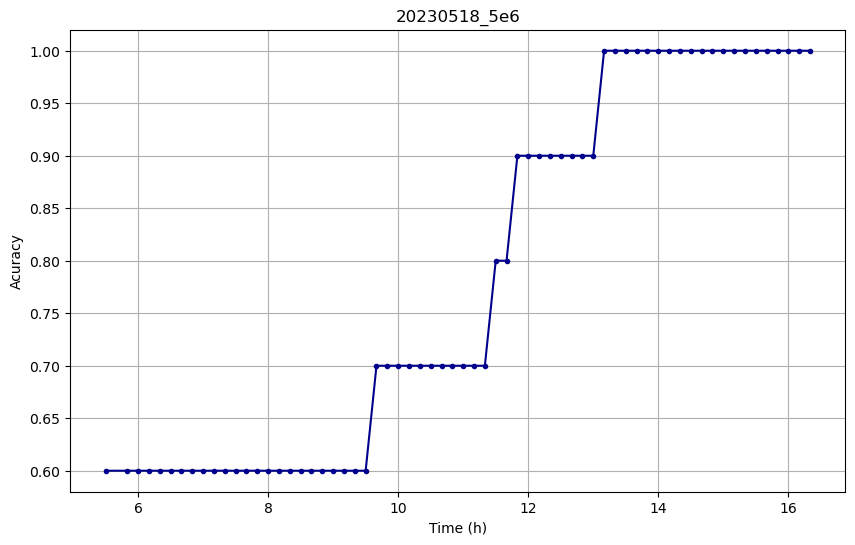

In [24]:
df_results = pd.DataFrame(accuracies_top1_2_t1)
df_results = df_results.sort_values(by="time")

#Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("20230518_5e6")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

### 6.3 Test 2

In [25]:
timepoints = df_test2[df_test2["std_atual"] > 0.05]["tempo"].unique()
accuracies_top1_2_t2 = []

for t in timepoints:
    df_t  = df_test2[df_test2["tempo"] == t]
    X_t   = df_t[features_novas]
    y_t   = df_t[label]

    preds = model_rf.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_top1_2_t2.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t:.2f}h  |  Accuracy: {acc:.4f}")
    print(result.to_string(index=False), "\n")

Time: 3.17h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.33h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.50h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.67h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 4.00h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1      

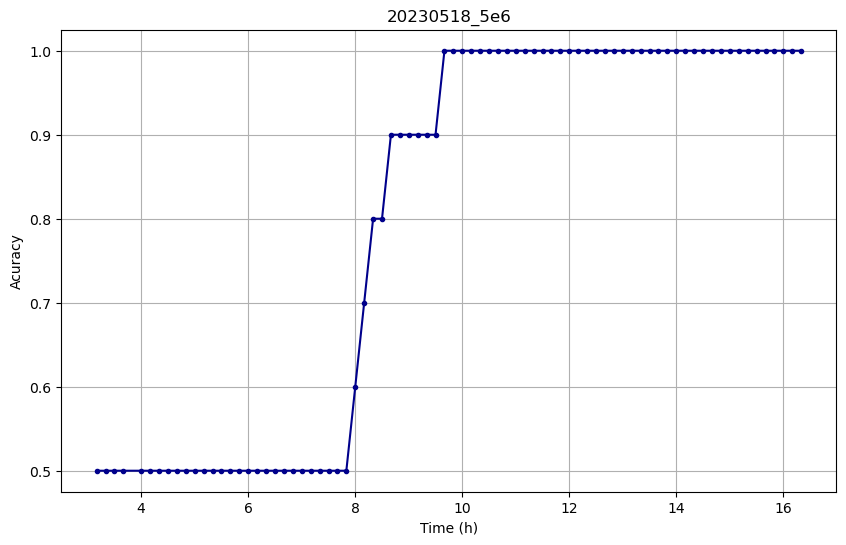

In [26]:
df_results = pd.DataFrame(accuracies_top1_2_t2)
df_results = df_results.sort_values(by="time")

#Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("20230518_5e6")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

### 7. Without derivative + initial_std (7 features) — Best Combination

In [27]:
#features_antigas['tempo', 'gvr', 'std_inicial', 'std_atual', 'std_tubo', 'slope', 'delta', 'AUC', 'Derivada']
features_novas = ['tempo', 'gvr', 'std_atual', 'std_tubo', 'slope', 'delta', 'AUC']

colunas = list(dataset.head(0))
label = colunas[-1]

print("Features:", features_novas)


experiencias = dataset["experiencia"].unique()

# experiencia de teste 1 e 2
exp_teste1 = "20230518_5e4"
exp_teste2 = "20230518_5e6"

# treino: todas as experiencias menos as 2 de teste
df_train = dataset[~dataset["experiencia"].isin([exp_teste1, exp_teste2])]

# teste 1 e teste 2
df_test1 = dataset[dataset["experiencia"] == exp_teste1]
df_test2 = dataset[dataset["experiencia"] == exp_teste2]

X_train = df_train[features_novas]
y_train = df_train["label"]

X_test1 = df_test1[features_novas]
y_test1 = df_test1["label"]

X_test2 = df_test2[features_novas]
y_test2 = df_test2["label"]


print(f"Train size : {len(df_train)} rows")
print(f"Test 1     : {len(df_test1)} rows  ({exp_teste1})")
print(f"Test 2     : {len(df_test2)} rows  ({exp_teste2})")

Features: ['tempo', 'gvr', 'std_atual', 'std_tubo', 'slope', 'delta', 'AUC']
Train size : 5450 rows
Test 1     : 990 rows  (20230518_5e4)
Test 2     : 990 rows  (20230518_5e6)


In [28]:
print(f"Testeset 1 shape after: {df_test1.shape}")
print(f"Testeset 1 shape after: {df_test2.shape}")
print(f"Train set shape after: {X_train.shape}")

Testeset 1 shape after: (990, 22)
Testeset 1 shape after: (990, 22)
Train set shape after: (5450, 7)


### 7.1 Train Model

In [29]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 7.2 Test 1

In [30]:
timepoints = df_test1[df_test1["std_atual"] > 0.05]["tempo"].unique()
accuracies_best_t1 = []

for t in timepoints:
    df_t  = df_test1[df_test1["tempo"] == t]
    X_t   = df_t[features_novas]
    y_t   = df_t[label]

    preds = model_rf.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_best_t1.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t:.2f}h  |  Accuracy: {acc:.4f}")
    print(result.to_string(index=False), "\n")

Time: 5.50h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          0
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 5.83h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.00h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.17h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.33h  |  Accuracy: 0.6000
 real  predicted
    1          1
    1          1
    1          1
    1      

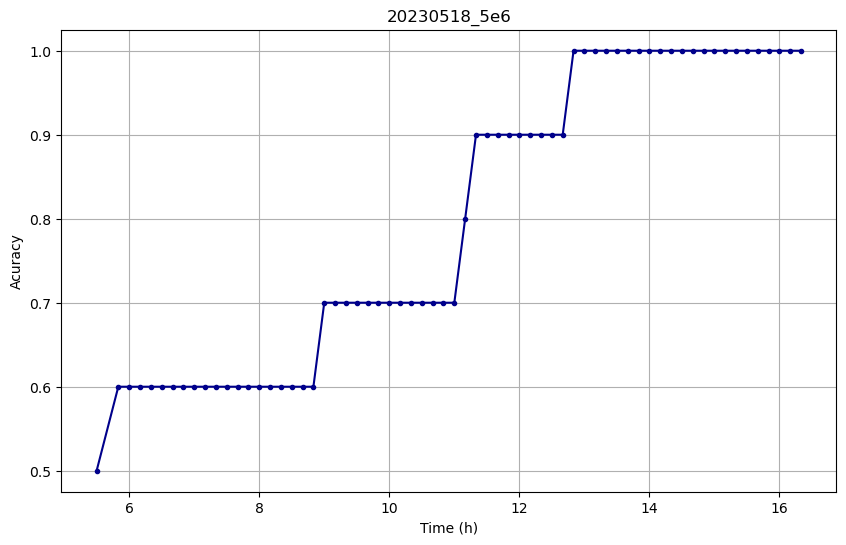

In [31]:
df_results = pd.DataFrame(accuracies_best_t1)
df_results = df_results.sort_values(by="time")

#Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("20230518_5e6")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

### 7.3 Test 2

In [32]:
timepoints = df_test2[df_test2["std_atual"] > 0.05]["tempo"].unique()
accuracies_best_t2 = []

for t in timepoints:
    df_t  = df_test2[df_test2["tempo"] == t]
    X_t   = df_t[features_novas]
    y_t   = df_t[label]

    preds = model_rf.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_best_t2.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t:.2f}h  |  Accuracy: {acc:.4f}")
    print(result.to_string(index=False), "\n")

Time: 3.17h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.33h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.50h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1 

Time: 3.67h  |  Accuracy: 0.7000
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          0
    0          1
    0          1
    0          1
    0          0 

Time: 4.00h  |  Accuracy: 0.5000
 real  predicted
    1          1
    1          1
    1          1
    1      

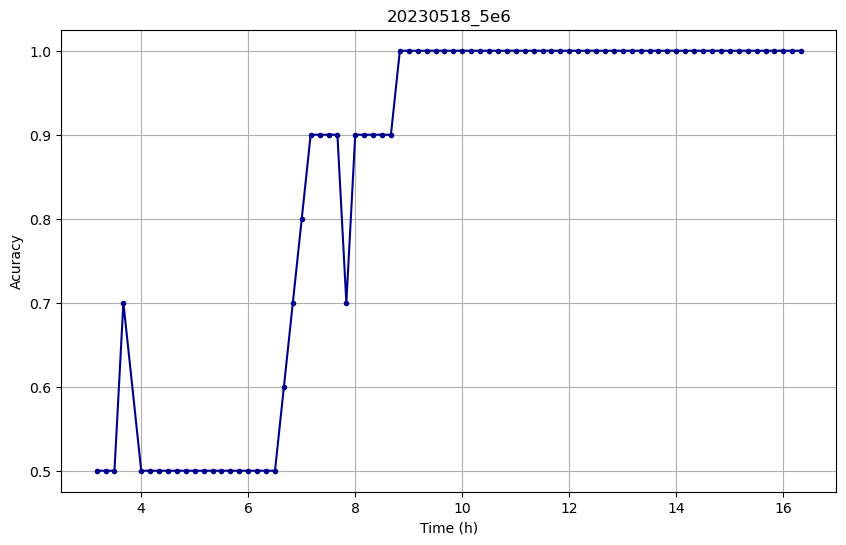

In [33]:
df_results = pd.DataFrame(accuracies_best_t2)
df_results = df_results.sort_values(by="time")

#Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("20230518_5e6")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()